In [ ]:
%pip install qiskit matplotlib qiskit[visualization]
%pip install qiskit-aer

### Quantum Full-Adder 구현
- input: 4 qubit
- output: 3 qubit

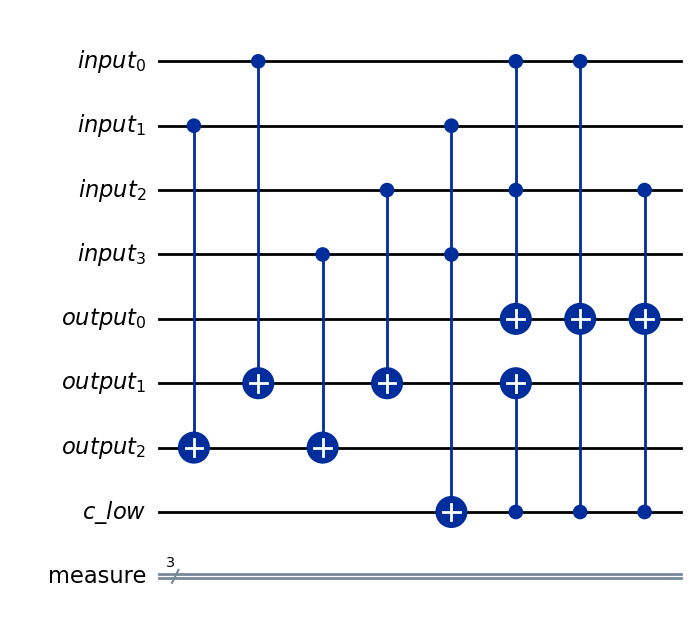

In [10]:
# 시뮬레이터 사용 소스코드 예제 (무료, 무한정)
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# 입력: x, y (number 1) / z, w (number 2) -> x, z는 MSB(2^1), y, w는 LSB(2^0)
inputs = QuantumRegister(4, "input")
# 출력: c, a(sum MSB), b(sum LSB)
outputs = QuantumRegister(3, "output")
carry_in = QuantumRegister(1, "c_low")
meas = ClassicalRegister(3, "measure")

qc = QuantumCircuit(inputs, outputs, carry_in, meas)

# 1. LSB 계산
# b = y XOR w
qc.cx(inputs[1], outputs[2])
qc.cx(inputs[3], outputs[2])
# c_low = y AND w
qc.ccx(inputs[1], inputs[3], carry_in[0])

# 2. MSB 계산
# a = x XOR z XOR c_low
qc.cx(inputs[0], outputs[1])
qc.cx(inputs[2], outputs[1])
qc.cx(carry_in[0], outputs[1])

# 3. 최종 carry 계산
# c = (x AND z) XOR (c_low AND (x XOR z)) <-> c = (x AND z) XOR (c_low AND x) XOR (c_low AND z)
qc.ccx(inputs[0], inputs[2], outputs[0])
qc.ccx(inputs[0], carry_in[0], outputs[0])
qc.ccx(inputs[2], carry_in[0], outputs[0])

qc.draw(output="mpl", filename="adder.png")
